In [39]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from uncertainties import ufloat
from uncertainties.umath import sin, radians

In [40]:
angle_unc = 0.07

df = pd.read_excel("data/xst.xlsx", sheet_name="A4")
df.head()

,beta,R
0,2.0,3
1,2.1,6
2,2.2,9
3,2.3,8
4,2.4,10


In [41]:
k_beta_1 = ufloat(8.9, angle_unc)   # Erster scharfer Peak
k_alpha_1 = ufloat(10.0, angle_unc) # Höchster Peak

# Ordnung n=2 (bei etwa doppeltem Winkel)
k_beta_2 = ufloat(18.2, angle_unc)
k_alpha_2 = ufloat(20.5, angle_unc)

lambda_beta_1 = ufloat(61.89, 0.68)
lambda_alpha_1 = ufloat(69.71, 0.68)

lambda_beta_2 = ufloat(62.96, 0.3)
lambda_alpha_2 = ufloat(70.61, 0.33)

In [51]:
data = [
    {"Linie": "K_beta",  "n": 1, "theta": ufloat(8.9,  angle_unc), "lambda": ufloat(61.89, 0.68)},
    {"Linie": "K_alpha", "n": 1, "theta": ufloat(10.0, angle_unc), "lambda": ufloat(69.71, 0.68)},
    {"Linie": "K_beta",  "n": 2, "theta": ufloat(18.2, angle_unc), "lambda": ufloat(62.96, 0.30)},
    {"Linie": "K_alpha", "n": 2, "theta": ufloat(20.5, angle_unc), "lambda": ufloat(70.61, 0.33)}
]

df_a = pd.DataFrame(data)

# Formel: a = (n * lambda) / sin(theta)
df_a['a'] = df_a.apply(lambda row: (row['n'] * row['lambda']) / sin(radians(row['theta'])), axis=1)

# 3. Mittelwert berechnen
a_mean = sum(df_a['a']) / len(df_a['a'])

# 4. Tabelle anzeigen
print("Einzelergebnisse für LiF:")
print(df_a[['Linie', 'n', 'theta', 'lambda', 'a']].to_string(index=False))

print("-" * 50)
print(f"Gemittelte Gitterkonstante a_LiF: {a_mean:.2fP} pm")
d_mean = a_mean / 2
print(f"Gemittelte Gitterkonstante d_LiF: {d_mean:.2fP} pm")

Einzelergebnisse für LiF:
  Linie  n        theta       lambda           a
 K_beta  1  8.90+/-0.07   61.9+/-0.7     400+/-5
K_alpha  1 10.00+/-0.07   69.7+/-0.7     401+/-5
 K_beta  2 18.20+/-0.07 62.96+/-0.30 403.2+/-2.4
K_alpha  2 20.50+/-0.07 70.61+/-0.33 403.2+/-2.3
--------------------------------------------------
Gemittelte Gitterkonstante a_LiF: 401.97±1.99 pm
Gemittelte Gitterkonstante d_LiF: 200.99±0.99 pm


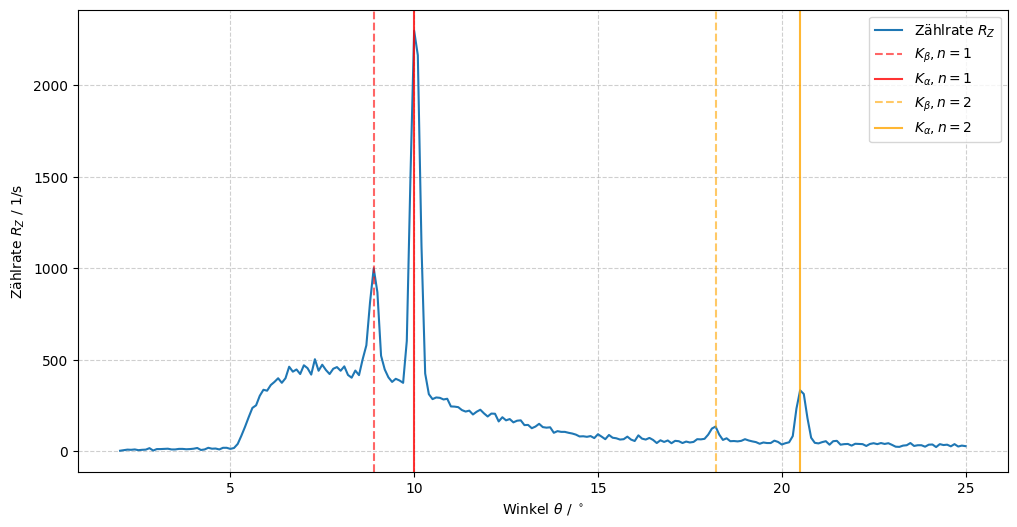

In [44]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df["beta"], df["R"], linestyle='-', label='Zählrate $R_Z$')

ax.set_xlabel(r"Winkel $\theta$ / $^\circ$")
ax.set_ylabel(r"Zählrate $R_Z$ / 1/s")

ax.grid(True, linestyle='--', alpha=0.6)

# 2. Vertikale Linien einzeichnen
# Erste Ordnung (Rot)
ax.axvline(x=k_beta_1.nominal_value, color='red', linestyle='--', alpha=0.6, label=r"$K_\beta, n=1$")
ax.axvline(x=k_alpha_1.nominal_value, color='red', linestyle='-', alpha=0.8, label=r"$K_\alpha, n=1$")

# Zweite Ordnung (z.B. Orange zur Unterscheidung)
ax.axvline(x=k_beta_2.nominal_value, color='orange', linestyle='--', alpha=0.6, label=r"$K_\beta, n=2$")
ax.axvline(x=k_alpha_2.nominal_value, color='orange', linestyle='-', alpha=0.8, label=r"$K_\alpha, n=2$")

ax.legend()

plt.show()